# Life style gene content

In [5]:
# 1. SETUP

PROJ <- "path/"
PROJ <- normalizePath(PROJ, mustWork = TRUE)
setwd(PROJ)

dir.create(file.path(PROJ, "outputs", "figures"), recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(PROJ, "outputs", "tables"),  recursive = TRUE, showWarnings = FALSE)

suppressMessages(library(ggplot2))

THEME <- theme_bw(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        plot.title = element_text(face = "bold"),
        legend.position = "right")

COL <- c(Temperate = "#2A9D8F", Virulent = "#E76F51",
         Lysogeny  = "#2A9D8F", Replication = "#8D99AE",
         Structural = "#457B9D", Lysis = "#E76F51")

save_fig <- function(p, name, w, h) {
  ggsave(file.path("outputs", "figures", paste0(name, ".pdf")), p, width = w, height = h)
  ggsave(file.path("outputs", "figures", paste0(name, ".svg")), p, width = w, height = h)
  invisible(p)
}

In [10]:
# 2. THE SINGLE DEFINITION
# RE_LYSOGENY reproduces the list verified:
# identical genome-level calls, 81/141. Six of that list's terms match zero
# genes in this dataset and are therefore dropped for clarity, with no effect
# on the result: "integron", "lysogen", "lysogenic", "attp", "attb", and
# "attachment site". "site-specific recombinase" is subsumed by "recombinase".

# The bare term "attachment" is deliberately absent; it is the false positive
# that produced the 60.3% figure.

RE_LYSOGENY   <- "integrase|recombinase|integration|xerc|xerd|prophage|excision"
RE_STRUCTURAL <- "terminase|portal|packaging|capsid|major_head|head-tail|prohead|\\btail\\b|baseplate|tail_fiber"
RE_LYSIS      <- "holin|endolysin|lysozyme|spanin"
RE_REPLICATION<- "dna[_ ]polymerase|helicase|primase|replication"

COV <- "data/Table_Cover_genes_Activegenomes.txt"
FAM <- "data/contigs_DNA_virus_family.txt"
CHK <- "data/CheckV_DNA_virome.txt"

In [11]:
# - 3. LOAD AND CLASSIFY

g <- read.table(COV, header = TRUE, sep = "\t", quote = "",
                comment.char = "", check.names = FALSE)
gen     <- g$Genome
genomes <- unique(gen)
cat(sprintf("%d genes, %d genomes\n", nrow(g), length(genomes)))

# genome-level content calls: TRUE if ANY gene in the genome matches
content <- function(re) tapply(grepl(re, g$Gene, ignore.case = TRUE), gen, any)[genomes]

has_lyso   <- content(RE_LYSOGENY)
has_struct <- content(RE_STRUCTURAL)
has_lysis  <- content(RE_LYSIS)
has_repl   <- content(RE_REPLICATION)

lifestyle <- ifelse(has_lyso, "Temperate", "Virulent")

# CheckV provirus calls, aligned to the same genome order
chk  <- read.table(CHK, header = TRUE, sep = "\t", quote = "", comment.char = "")
prov <- setNames(chk$provirus == "Yes", chk$contig_id)[genomes]
prov[is.na(prov)] <- FALSE

# family labels (strip the trailing _<number> that the family file carries)
fam <- read.table(FAM, header = TRUE, sep = "\t", quote = "", comment.char = "")
fam$fam <- sub("_$", "", sub("_[0-9]+$", "", fam$family))
family  <- fam$fam[match(genomes, fam$contig_name)]
family[is.na(family)] <- "Unmapped"

n <- length(genomes)
pct <- function(x) 100 * sum(x) / n

13853 genes, 141 genomes


Warning message in scan(file = file, what = what, sep = sep, quote = quote, dec = dec, :
“number of items read is not a multiple of the number of columns”


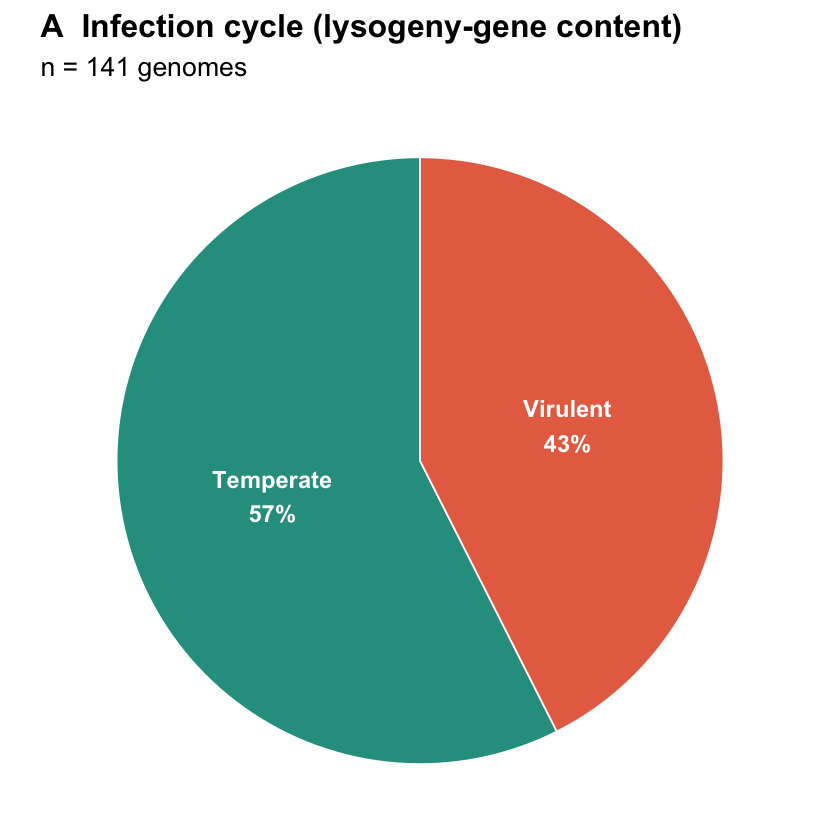

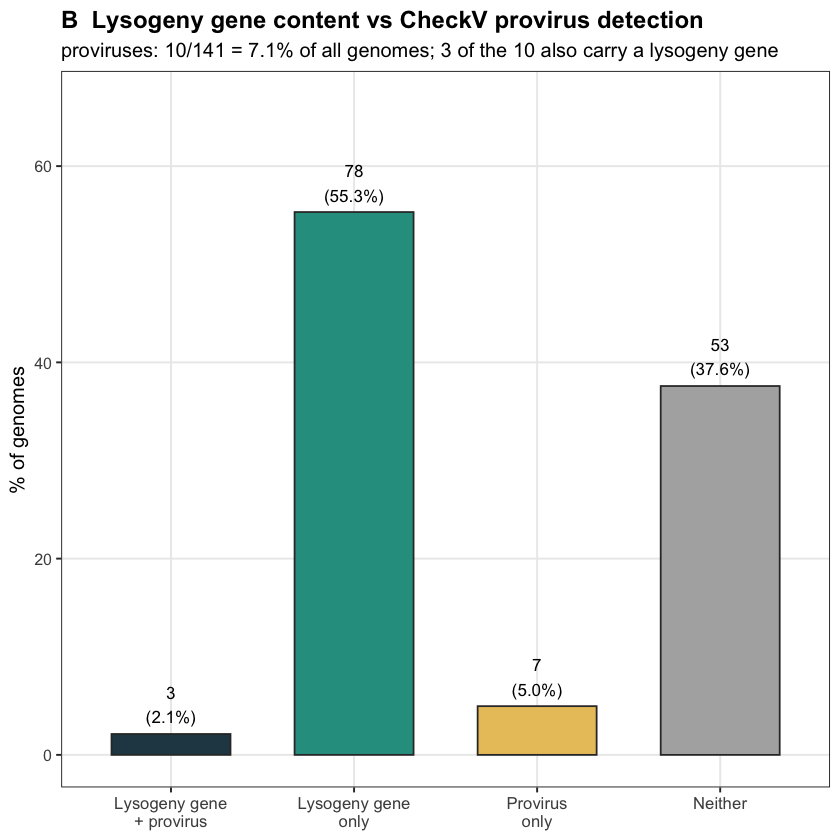

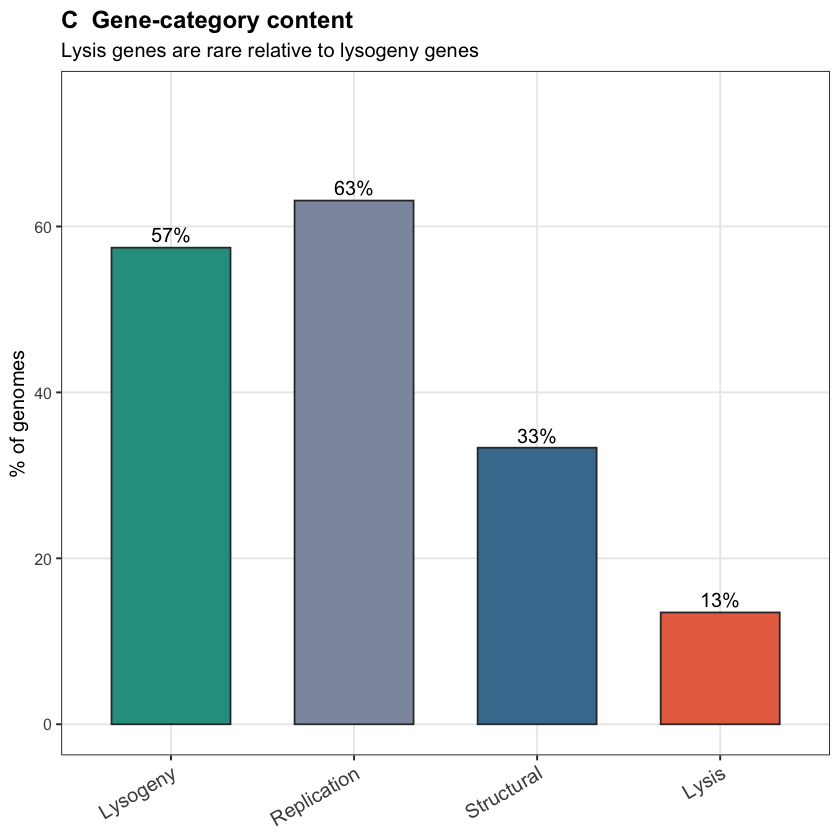


=========================  VALUES LIFESTYLE =========================
genomes analysed                 : 141
temperate (lysogeny gene present): 81  = 57.4%   -> report "57%"
no lysogeny gene detected        : 60  = 42.6%   -> report "43%"
CheckV proviruses                : 10  = 7.1%   -> report "7%" OF ALL GENOMES
  proviruses with a lysogeny gene: 3 of 10  (= 3.7% of the 81 temperate)
  proviruses without             : 7   <- these are called "virulent" by gene content
gene content: lysogeny 57%  replication 63%  structural 33%  lysis 13%

--- by family (n >= 3) ---
            family n_genomes temperate temperate_pct provirus structural lysis
   Inoviridae_like         6         6         100.0        0          1     1
 Adenoviridae_like         5         4          80.0        0          0     0
      Peduoviridae        74        45          60.8        0         18     8
      Siphoviridae         4         2          50.0        4          4     2
    Family_unknown        28 

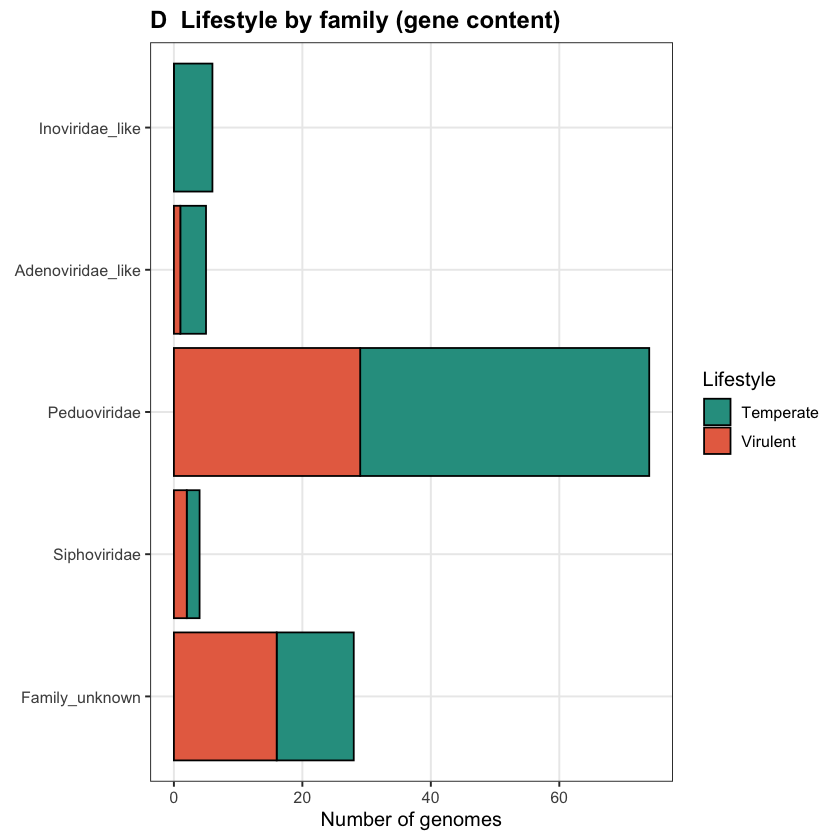

In [15]:
# PANEL A — temperate vs virulent

dA <- as.data.frame(table(Lifestyle = lifestyle))
dA$pct <- 100 * dA$Freq / sum(dA$Freq)

pA <- ggplot(dA, aes("", pct, fill = Lifestyle)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y") +
  scale_fill_manual(values = COL[c("Temperate", "Virulent")]) +
  geom_text(aes(label = sprintf("%s\n%.0f%%", Lifestyle, pct)),
            position = position_stack(vjust = .5),
            size = 5, color = "white", fontface = "bold") +
  labs(title = "A  Infection cycle (lysogeny-gene content)",
       subtitle = sprintf("n = %d genomes", n)) +
  theme_void(base_size = 16) +
  theme(plot.title = element_text(face = "bold"), legend.position = "none")

print(pA)
save_fig(pA, "PanelA_lifestyle_gene_content", 3.8, 3.8)


# 5. PANEL B — prophages, reported without nesting
# only 3 of the 10 CheckV proviruses carry a
# detected lysogeny gene, so the prophages are not a subset of the temperate
# set.
# This panel shows the four MUTUALLY EXCLUSIVE groups, which sum to n, so the
# relationship between the two piece of evidence is visible rather than assumed.

grp <- ifelse( has_lyso &  prov, "Lysogeny gene\n+ provirus",
        ifelse( has_lyso & !prov, "Lysogeny gene\nonly",
         ifelse(!has_lyso &  prov, "Provirus\nonly", "Neither")))
LEV <- c("Lysogeny gene\n+ provirus", "Lysogeny gene\nonly",
         "Provirus\nonly", "Neither")

dB <- as.data.frame(table(Group = factor(grp, levels = LEV)))
dB$pct <- 100 * dB$Freq / sum(dB$Freq)
stopifnot(sum(dB$Freq) == n)   # the four groups must partition all genomes

pB <- ggplot(dB, aes(Group, pct, fill = Group)) +
  geom_col(color = "grey20", width = .65, show.legend = FALSE) +
  geom_text(aes(label = sprintf("%d\n(%.1f%%)", Freq, pct)), vjust = -0.3, size = 3.6) +
  scale_fill_manual(values = c("#264653", "#2A9D8F", "#E9C46A", "#B0B0B0")) +
  ylim(0, max(dB$pct) * 1.2) +
  labs(title = "B  Lysogeny gene content vs CheckV provirus detection",
       subtitle = sprintf("proviruses: %d/%d = %.1f%% of all genomes; %d of the %d also carry a lysogeny gene",
                          sum(prov), n, pct(prov), sum(has_lyso & prov), sum(prov)),
       y = "% of genomes", x = NULL) +
  THEME + theme(axis.text.x = element_text(size = 10))

print(pB)
save_fig(pB, "PanelB_prophage_reconciliation", 6.5, 4.2)

# 6. PANEL C. gene-content categories (all genomes)
# Same regexes as everything else, this panel reads 57% for lysogeny.

dC <- data.frame(
  Category = factor(c("Lysogeny", "Replication", "Structural", "Lysis"),
                    levels = c("Lysogeny", "Replication", "Structural", "Lysis")),
  pct = c(pct(has_lyso), pct(has_repl), pct(has_struct), pct(has_lysis)))

pC <- ggplot(dC, aes(Category, pct, fill = Category)) +
  geom_col(color = "grey20", width = .65, show.legend = FALSE) +
  geom_text(aes(label = sprintf("%.0f%%", pct)), vjust = -0.4, size = 4.2) +
  scale_fill_manual(values = COL[c("Lysogeny", "Replication", "Structural", "Lysis")]) +
  ylim(0, 75) +
  labs(title = "C  Gene-category content",
       subtitle = "Lysis genes are rare relative to lysogeny genes",
       y = "% of genomes", x = NULL) +
  THEME + theme(axis.text.x = element_text(angle = 30, hjust = 1, size = 12))

print(pC)
save_fig(pC, "PanelC_gene_category_content", 4.6, 4)


# 7. PANEL D. lifestyle by family
# Families with >= 3 genomes only; "Unmapped" excluded. Ordered by the
# temperate proportion so the gradient is readable.

keep <- setdiff(names(which(table(family) >= 3)), "Unmapped")
sel  <- family %in% keep

dD <- as.data.frame(table(Family   = family[sel],
                          Lifestyle = lifestyle[sel]))
colnames(dD) <- c("Family", "Lifestyle", "nG")
ordF <- names(sort(tapply(lifestyle[sel] == "Temperate", family[sel], mean)))
dD$Family <- factor(dD$Family, levels = ordF)

pD <- ggplot(dD, aes(Family, nG, fill = Lifestyle)) +
  geom_col(color = "black", linewidth = 0.5) +
  coord_flip() +
  scale_fill_manual(values = COL[c("Temperate", "Virulent")]) +
  labs(title = "D  Lifestyle by family (gene content)",
       y = "Number of genomes", x = NULL) +
  THEME

print(pD)
save_fig(pD, "PanelD_lifestyle_by_family", 7.5, 4)


# 8. TABLES AND SENSITIVITY

# per-genome calls
per_genome <- data.frame(
  genome = genomes, family = family, lifestyle = lifestyle,
  lysogeny_gene = as.logical(has_lyso), checkv_provirus = as.logical(prov),
  structural = as.logical(has_struct), lysis = as.logical(has_lysis),
  replication = as.logical(has_repl), row.names = NULL)
write.csv(per_genome, "outputs/tables/Table_lifestyle_per_genome.csv", row.names = FALSE)

# family summary
fam_tab <- do.call(rbind, lapply(keep, function(f) {
  m <- family == f
  data.frame(family = f, n_genomes = sum(m),
             temperate = sum(has_lyso[m]),
             temperate_pct = round(100 * mean(has_lyso[m]), 1),
             provirus = sum(prov[m]),
             structural = sum(has_struct[m]), lysis = sum(has_lysis[m]))
}))
fam_tab <- fam_tab[order(-fam_tab$temperate_pct), ]
write.csv(fam_tab, "outputs/tables/Table_lifestyle_by_family.csv", row.names = FALSE)

# SENSITIVITY
alt <- list(
  "permissive (+attachment)" = "integrase|recombinase|excisionase|prophage|integration|xerc|xerd|attachment|integron|lysogen",
  "USED (this script)"       = RE_LYSOGENY,
  "narrow (no integration)"  = "integrase|recombinase|xerc|xerd|excisionase|prophage|integron",
  "integrase/xer only"       = "integrase|xerc|xerd|excisionase|prophage")
sens <- do.call(rbind, lapply(names(alt), function(k) {
  h <- content(alt[[k]])
  data.frame(definition = k, temperate = sum(h), virulent = n - sum(h),
             temperate_pct = round(100 * mean(h), 1))
}))
write.csv(sens, "outputs/tables/Table_lifestyle_sensitivity.csv", row.names = FALSE)


# 9. Results

cat("\n=========================  VALUES =========================\n")
cat(sprintf("genomes analysed                 : %d\n", n))
cat(sprintf("temperate (lysogeny gene present): %d  = %.1f%%   -> report \"57%%\"\n",
            sum(has_lyso), pct(has_lyso)))
cat(sprintf("no lysogeny gene detected        : %d  = %.1f%%   -> report \"43%%\"\n",
            n - sum(has_lyso), 100 - pct(has_lyso)))
cat(sprintf("CheckV proviruses                : %d  = %.1f%%   -> report \"7%%\" OF ALL GENOMES\n",
            sum(prov), pct(prov)))
cat(sprintf("  proviruses with a lysogeny gene: %d of %d  (= %.1f%% of the %d temperate)\n",
            sum(has_lyso & prov), sum(prov), 100 * sum(has_lyso & prov) / sum(has_lyso), sum(has_lyso)))
cat(sprintf("  proviruses without             : %d   <- these are called \"virulent\" by gene content\n",
            sum(!has_lyso & prov)))
cat(sprintf("gene content: lysogeny %.0f%%  replication %.0f%%  structural %.0f%%  lysis %.0f%%\n",
            pct(has_lyso), pct(has_repl), pct(has_struct), pct(has_lysis)))

cat("\n--- by family (n >= 3) ---\n")
print(fam_tab, row.names = FALSE)


stopifnot(sum(has_lyso) == 81, sum(prov) == 10, n == 141)
cat("\nSelf-check passed: 81 temperate, 60 virulent, 10 proviruses, n = 141.\n")
cat("Figures -> outputs/figures/ , tables -> outputs/tables/\n")


In [14]:
sessionInfo()

R version 4.1.1 (2021-08-10)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS 26.4.1

Matrix products: default
BLAS/LAPACK: /Users/au657143/mambaforge/envs/maaslin/lib/libopenblasp-r0.3.23.dylib

locale:
[1] en_AU/en_AU/en_AU/C/en_AU/en_AU

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_3.5.2

loaded via a namespace (and not attached):
 [1] magrittr_2.0.3     tidyselect_1.2.1   uuid_1.2-0         R6_2.6.1          
 [5] ragg_1.2.7         rlang_1.1.6        fastmap_1.1.1      dplyr_1.1.4       
 [9] tools_4.1.1        dichromat_2.0-0.1  grid_4.1.1         gtable_0.3.6      
[13] cli_3.6.5          withr_3.0.2        systemfonts_1.0.5  htmltools_0.5.7   
[17] digest_0.6.37      tibble_3.3.0       lifecycle_1.0.4    crayon_1.5.3      
[21] textshaping_0.3.7  IRdisplay_1.1      RColorBrewer_1.1-3 farver_2.1.2      
[25] repr_1.1.6         base64enc_0.1-3    vctrs_0.6.5        IRkernel